# Wisconsin Diagnostic Breast Cancer

Dataset-specific starting notebook for the DataFrameSampler paper experiments.

Claim-specific role: small medical binary-classification benchmark for clinical-style software examples, distributional checks, and downstream diagnostic-label utility.


## Setup

Run the downloader before executing this notebook:

```bash
python experiments/download_datasets.py
```

Dataset-specific choices live in `experiments/datasets.py`; the reusable execution path lives in `experiments/workflow.py`.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distribution_comparison, plot_pairwise_feature_comparison
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.sensitivity_validation import summarize_sensitivity_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.workflow import dataset_profile, experiment_paths, load_dataset, notebook_environment, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import preprocessing_plan, vectorization_plan

DATASET_NAME = "breast_cancer"
CONFIG = DATASET_CONFIGS[DATASET_NAME]
PATHS = experiment_paths(CONFIG, root=ROOT)
notebook_environment(PATHS)


{'python': '3.11.13',
 'pandas': '2.3.3',
 'dataset': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/breast_cancer.csv'}

## Load Prepared Data

Exploration uses the prepared source dataframe before the experiment workflow fits or samples anything.


In [2]:
dataframe = load_dataset(CONFIG, root=ROOT)
work = working_dataframe(dataframe, CONFIG)
profile = dataset_profile(dataframe)
dataframe.shape, dataframe.head()


((569, 31),
    diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
 0  malignant        17.99         10.38          122.80     1001.0   
 1  malignant        20.57         17.77          132.90     1326.0   
 2  malignant        19.69         21.25          130.00     1203.0   
 3  malignant        11.42         20.38           77.58      386.1   
 4  malignant        20.29         14.34          135.10     1297.0   
 
    mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
 0          0.11840           0.27760          0.3001              0.14710   
 1          0.08474           0.07864          0.0869              0.07017   
 2          0.10960           0.15990          0.1974              0.12790   
 3          0.14250           0.28390          0.2414              0.10520   
 4          0.10030           0.13280          0.1980              0.10430   
 
    mean_symmetry  ...  worst_radius  worst_texture  worst_perimeter  \
 0         0.2419 

## Target Column Choice

The predictive task uses this target column from the prepared dataframe.

In [3]:
target_column_choice(CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,diagnosis,classification,True,2,0,Configured in experiments/datasets.py and used...


## Dataset Profile

The reusable breast-cancer configuration runs on the full prepared table. The source identifier is dropped during preparation; the diagnosis label is retained as the target column.


In [4]:
profile


,dtype,missing,unique
diagnosis,object,0,2
mean_radius,float64,0,456
mean_texture,float64,0,479
mean_perimeter,float64,0,522
mean_area,float64,0,539
mean_smoothness,float64,0,474
mean_compactness,float64,0,537
mean_concavity,float64,0,537
mean_concave_points,float64,0,542
mean_symmetry,float64,0,432


## Column Vectorization Plan

These are the columns that require vectorization before latent learning. The table records whether each column is numeric, directly mapped, discarded as high-cardinality, binary categorical, or NCA latent encoded to one numeric coordinate.


In [5]:
pre_plan = preprocessing_plan(CONFIG)
if not pre_plan.empty:
    display(pre_plan)

vector_plan = vectorization_plan(dataframe, CONFIG)
vector_plan[vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,strategy,latent_components,high_cardinality_warning,rationale
0,diagnosis,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

These cells summarize the original columns before the workflow runs. Original-vs-generated visual comparisons appear after `run_configured_dataset_experiment`, once generated rows are available.


In [6]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,diagnosis,object,0.0,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,benign: 0.63; malignant: 0.37
1,mean_radius,float64,0.0,456,numeric,14.127292,3.524049,6.981,13.37,28.11,
2,mean_texture,float64,0.0,479,numeric,19.289649,4.301036,9.71,18.84,39.28,
3,mean_perimeter,float64,0.0,522,numeric,91.969033,24.298981,43.79,86.24,188.5,
4,mean_area,float64,0.0,539,numeric,654.889104,351.914129,143.5,551.1,2501.0,
5,mean_smoothness,float64,0.0,474,numeric,0.09636,0.014064,0.05263,0.09587,0.1634,
6,mean_compactness,float64,0.0,537,numeric,0.104341,0.052813,0.01938,0.09263,0.3454,
7,mean_concavity,float64,0.0,537,numeric,0.088799,0.07972,0.0,0.06154,0.4268,
8,mean_concave_points,float64,0.0,542,numeric,0.048919,0.038803,0.0,0.0335,0.2012,
9,mean_symmetry,float64,0.0,432,numeric,0.181162,0.027414,0.106,0.1792,0.304,


## Run Experiment

The full sampler/baseline workflow runs after the exploratory cells.


In [7]:
result = run_configured_dataset_experiment(CONFIG, root=ROOT)
result.paths


ExperimentPaths(root=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler'), data_path=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/breast_cancer.csv'), results_dir=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/results'))

## Original vs Generated Visual Comparison

These plots overlay the working original dataframe and the generated DataFrameSampler rows using shared axes and different colors.


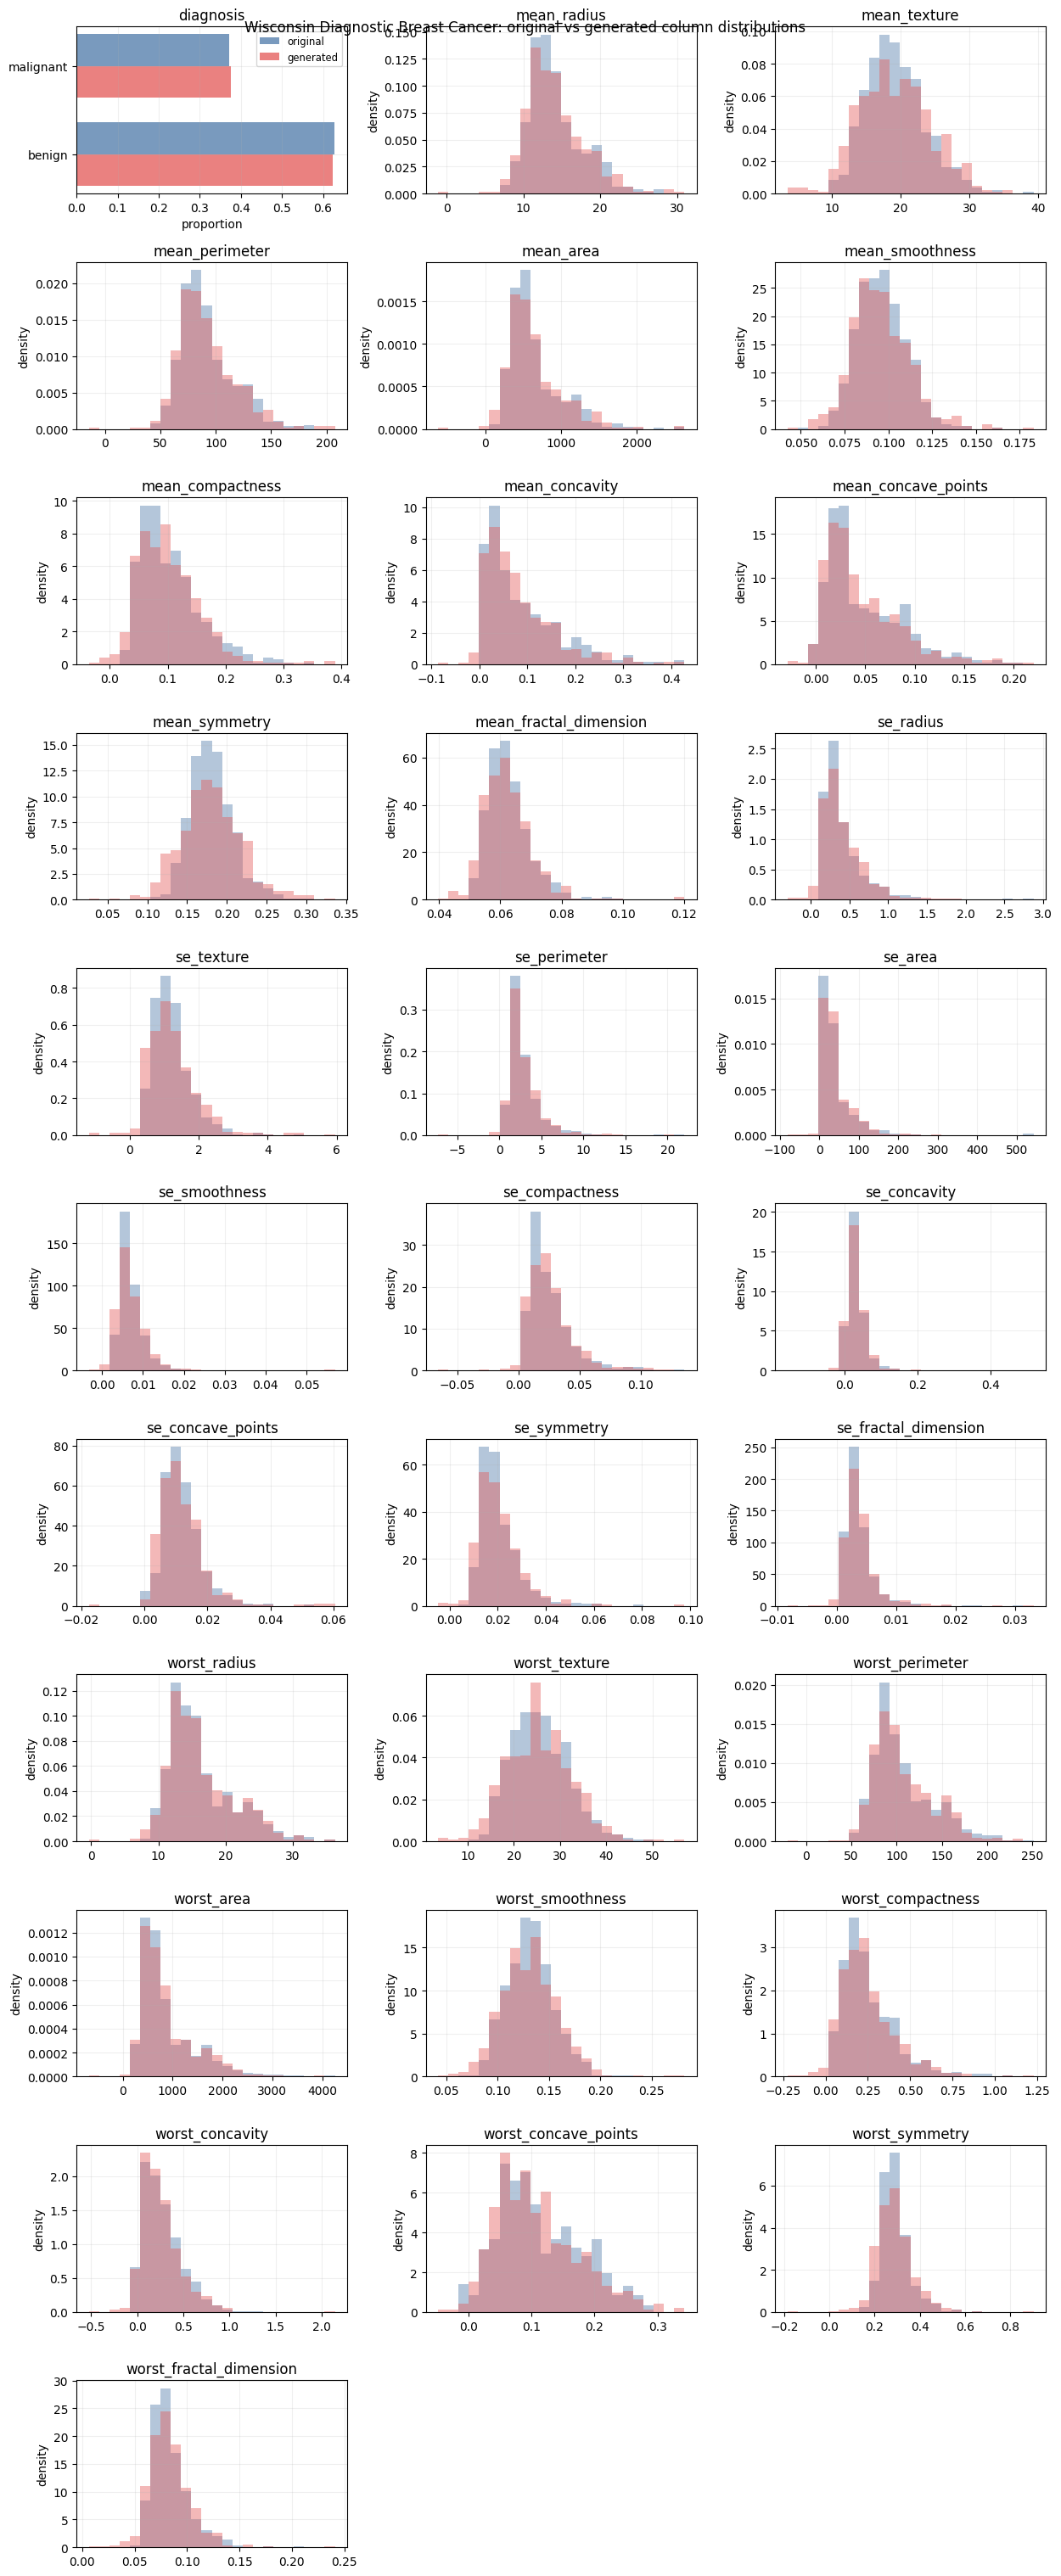

In [8]:
_ = plot_column_distribution_comparison(result.working_dataframe, result.starter_run.generated, title="Wisconsin Diagnostic Breast Cancer")


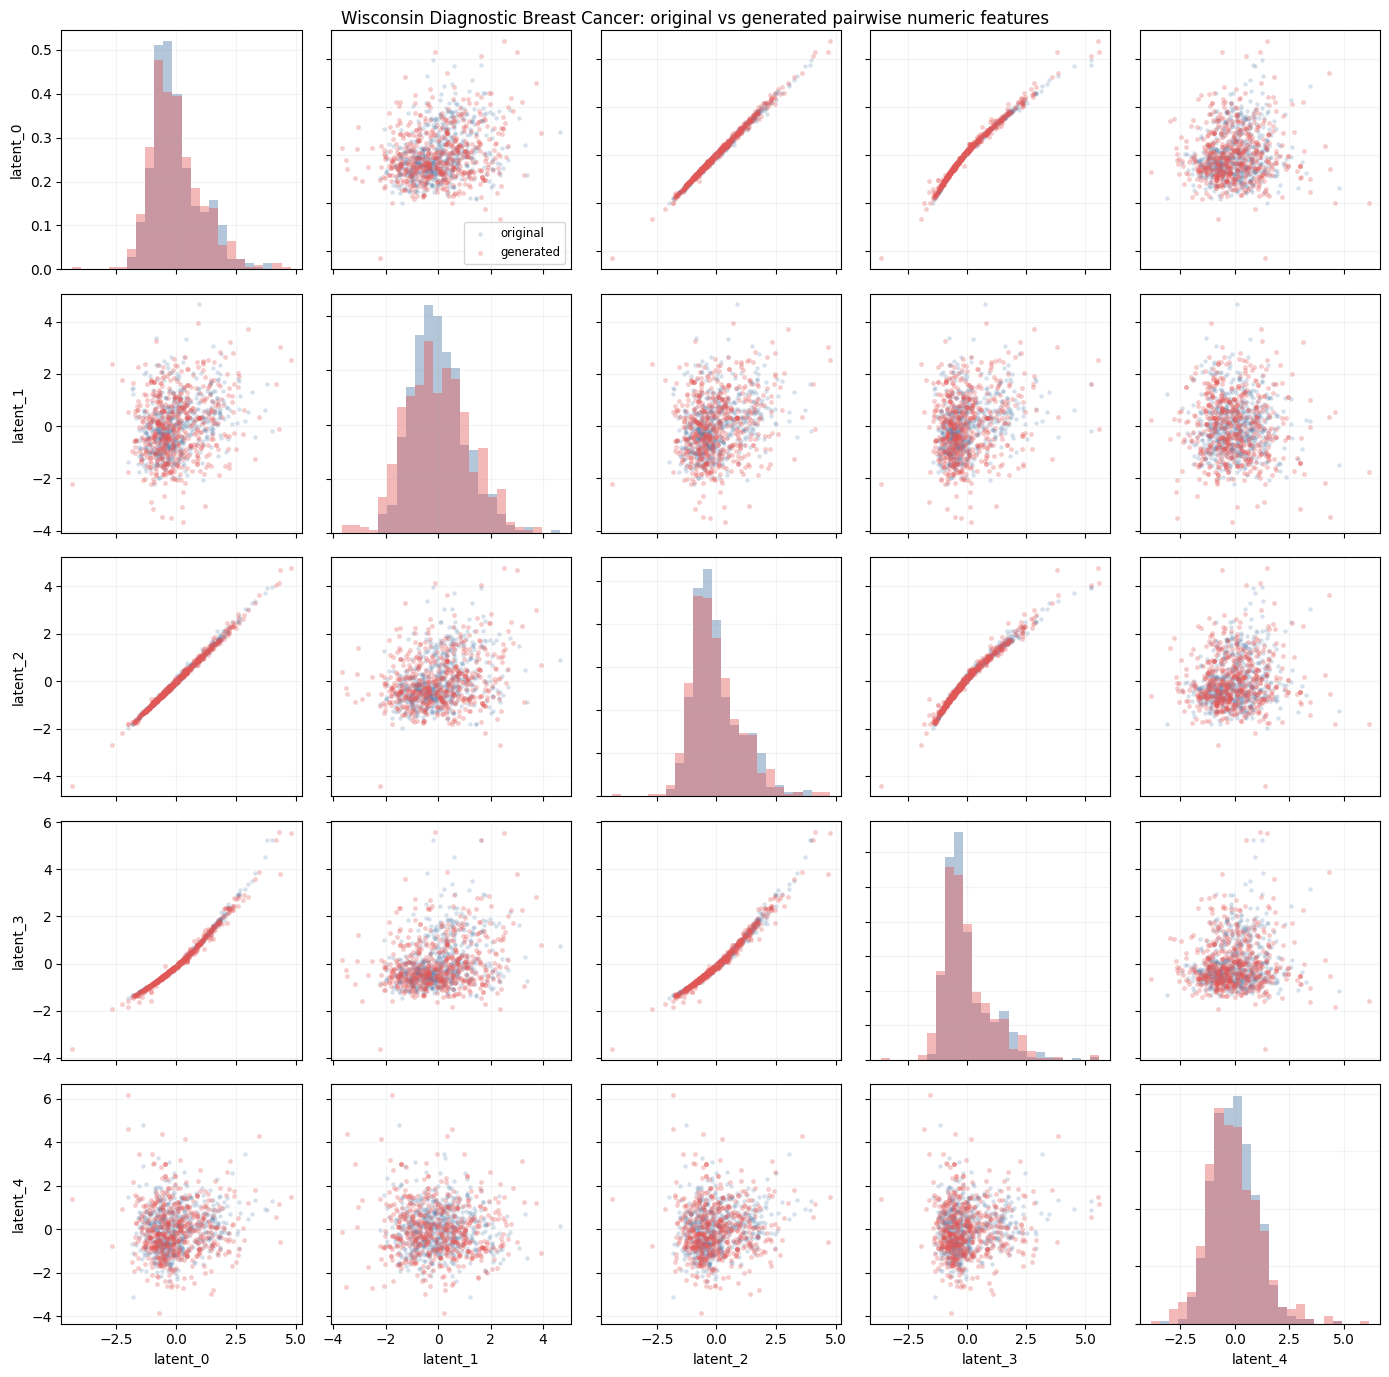

In [9]:
original_numeric = numeric_view(result.working_dataframe, result.starter_run.sampler)
generated_numeric = numeric_view(result.starter_run.generated, result.starter_run.sampler)
_ = plot_pairwise_feature_comparison(original_numeric, generated_numeric, target_column=CONFIG.target_column, title="Wisconsin Diagnostic Breast Cancer", max_numeric=None if "adult" == CONFIG.dataset_name else 5)


## Starter DataFrameSampler Run

The workflow writes the generated starter sample, quick similarity report, and runtime row to `experiments/results/`.


In [10]:
result.starter_run.fit_seconds, result.starter_run.sample_seconds, result.starter_run.generated.head()


(5.363431771984324,
 1.231628704990726,
    diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
 0     benign       13.500         16.73           86.01      577.0   
 1     benign       11.660         22.54           73.60      417.6   
 2  malignant       15.230         22.35          103.10      728.3   
 3     benign       11.380         15.35           73.66      377.5   
 4     benign       12.741         19.02           80.17      471.5   
 
    mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
 0          0.09039           0.05505        0.029100             0.019410   
 1          0.07269           0.03684        0.004439             0.006958   
 2          0.08807           0.18490        0.204800             0.069330   
 3          0.07832           0.08925        0.055340             0.027000   
 4          0.11995          -0.01108       -0.035480             0.039720   
 
    mean_symmetry  ...  worst_radius  worst_texture  worst_per

In [11]:
result.starter_run.similarity_report


,column,kind,real_mean,synthetic_mean,abs_mean_delta,real_missing,synthetic_missing,real_unique,synthetic_unique,category_coverage
0,mean_radius,numeric,14.127292,14.108708,0.018583,0.0,0.0,NaN,NaN,NaN
1,mean_texture,numeric,19.289649,19.223128,0.066520,0.0,0.0,NaN,NaN,NaN
2,mean_perimeter,numeric,91.969033,91.731810,0.237223,0.0,0.0,NaN,NaN,NaN
3,mean_area,numeric,654.889104,647.931810,6.957293,0.0,0.0,NaN,NaN,NaN
4,mean_smoothness,numeric,0.096360,0.095849,0.000512,0.0,0.0,NaN,NaN,NaN
5,mean_compactness,numeric,0.104341,0.101321,0.003020,0.0,0.0,NaN,NaN,NaN
6,mean_concavity,numeric,0.088799,0.082604,0.006196,0.0,0.0,NaN,NaN,NaN
7,mean_concave_points,numeric,0.048919,0.046223,0.002696,0.0,0.0,NaN,NaN,NaN
8,mean_symmetry,numeric,0.181162,0.180666,0.000496,0.0,0.0,NaN,NaN,NaN
9,mean_fractal_dimension,numeric,0.062798,0.062285,0.000512,0.0,0.0,NaN,NaN,NaN


## Numeric Projection Of Generated Data

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


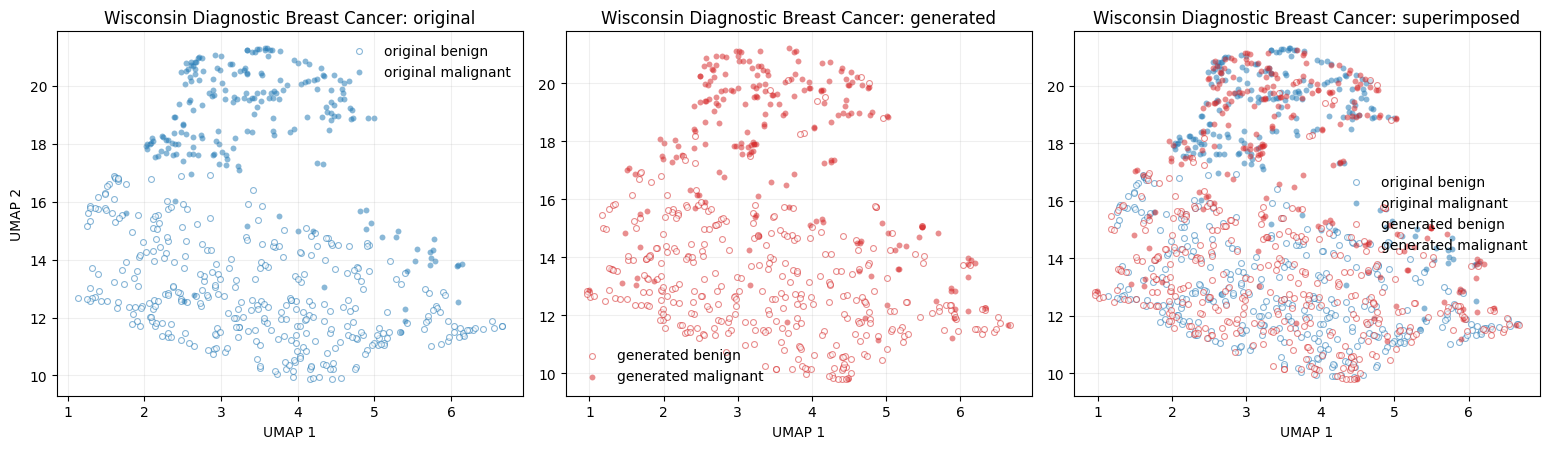

In [12]:
_ = plot_numeric_projection_triptych(
    result.starter_run.sampler,
    result.working_dataframe,
    result.starter_run.generated,
    target_column=CONFIG.target_column,
    title=CONFIG.title,
    reducer="umap",
    random_state=CONFIG.random_state,
)


## Baseline and Configuration Comparison

The same workflow runs DataFrameSampler and simple baselines and the simple baselines, then writes the comparison CSV.


In [13]:
result.comparison


,dataset,method,n_real,n_synthetic,numeric_mean_abs_error,numeric_std_abs_error,numeric_ks_statistic,numeric_wasserstein_distance,numeric_histogram_overlap,categorical_total_variation,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_numeric_kl,distribution_categorical_jsd,distribution_categorical_tv,distribution_similarity_score
0,breast_cancer,dataframe_sampler,569,569,0.620759,1.972778,0.066784,2.138084,0.903574,0.003515,...,0.497076,classification,0.970805,0.964796,-0.006009,0.903574,0.105531,0.000010,0.003515,0.966683
1,breast_cancer,gaussian_copula_empirical,569,569,0.258126,2.560207,0.031576,1.491377,0.953954,0.008787,...,0.836257,classification,0.970805,0.928417,-0.042387,0.953954,0.117857,0.000059,0.008787,0.981703
2,breast_cancer,independent_columns,569,569,1.349145,2.414351,0.035677,1.678149,0.943292,0.007030,...,0.000000,classification,0.970805,0.970500,-0.000305,0.943292,0.074215,0.000038,0.007030,0.978741
3,breast_cancer,row_bootstrap,569,569,1.204969,0.172828,0.037727,1.770837,0.945753,0.007030,...,0.701754,classification,0.970805,0.988304,0.017499,0.945753,0.049786,0.000038,0.007030,0.979562
4,breast_cancer,stratified_columns,569,569,0.983094,1.752058,0.033626,1.668226,0.947569,0.015817,...,0.035088,classification,0.970805,0.970805,0.000000,0.947569,0.078963,0.000195,0.015817,0.977186


In [14]:
summarize_manifold_validation(result.manifold_validation)


,dataset,method,out_hull_rate,real_stress_median,real_stress_q95,generated_stress_median,out_hull_stress_median,out_hull_acceptance_at_real_q95
0,breast_cancer,dataframe_sampler,1.0,0.036398,0.061186,0.037233,0.037233,0.904
1,breast_cancer,latent_bootstrap,0.0,0.036398,0.061186,0.033232,NaN,NaN
2,breast_cancer,latent_interpolation,0.0,0.036398,0.061186,0.033309,NaN,NaN


In [15]:
summarize_mechanism_validation(result.mechanism_validation)


,dataset,columns_evaluated,mean_cardinality,mean_nca_accuracy,mean_majority_accuracy,mean_pca_accuracy,mean_raw_context_accuracy,mean_lift_over_majority,mean_lift_over_pca
0,breast_cancer,1,2.0,0.976608,0.625731,0.953216,0.97076,0.350877,0.023392


In [16]:
summarize_decoder_calibration(result.decoder_calibration)


,dataset,cardinality_bucket,columns_evaluated,mean_accuracy,mean_top_confidence,mean_confidence_gap,mean_negative_log_loss,mean_brier_score,mean_expected_calibration_error
0,breast_cancer,binary,1,0.982456,0.931345,-0.051111,0.087783,0.043226,0.051111


## Predictive Target Evaluation

The real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [17]:
predictive_report = predictive_performance_report(work, CONFIG)
predictive_report


,dataset,target_column,task,training_source,accuracy,balanced_accuracy,f1_weighted,roc_auc,mae,rmse,r2,train_rows,test_rows
0,breast_cancer,diagnosis,classification,real_train,0.970760,0.970356,0.970805,0.998102,NaN,NaN,NaN,398,171
1,breast_cancer,diagnosis,classification,synthetic_from_real_train,0.959064,0.961011,0.959242,0.993867,NaN,NaN,NaN,398,171


In [18]:
summarize_sensitivity_validation(result.sensitivity_validation)


,parameter,value,setup_label,datasets_evaluated,n_iterations,max_constraint_retries,calibrate_decoders,mean_nn_distance_ratio,mean_discrimination_accuracy,mean_utility_lift,mean_distribution_similarity_score,mean_fit_seconds,mean_sample_seconds
